In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
import keras_tuner as kt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, f1_score,
                             confusion_matrix, classification_report)
from sklearn.utils.class_weight import compute_class_weight
import pickle
import gc
import warnings
warnings.filterwarnings('ignore')

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
    print(f"GPU: {gpus[0]}")

plt.rcParams['figure.dpi']       = 150
plt.rcParams['axes.facecolor']   = '#0d0d0d'
plt.rcParams['figure.facecolor'] = '#0d0d0d'
plt.rcParams['axes.edgecolor']   = '#444444'
plt.rcParams['axes.labelcolor']  = 'white'
plt.rcParams['xtick.color']      = 'white'
plt.rcParams['ytick.color']      = 'white'
plt.rcParams['text.color']       = 'white'
plt.rcParams['grid.color']       = '#222222'
plt.rcParams['grid.linestyle']   = '--'
plt.rcParams['grid.alpha']       = 0.4

core_path    = os.getcwd()
tuner_path   = os.path.join(core_path, 'tuner_logs_1')
os.makedirs(tuner_path,   exist_ok=True)

I0000 00:00:1779601589.343850  193455 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779601589.407516  193455 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779601590.801658  193455 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


GPU: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [2]:
orbital_df = pd.read_pickle(os.path.join(core_path, 'data/lvl3/orbital_df.pkl'))

FEATURES_A = ['a_p', 'e_p', 'sin_i_p', 'g', 's']

# Use family_1 directly — 0 = background, rest = family IDs
le = LabelEncoder()
y  = le.fit_transform(orbital_df['family_1'].values)
n_classes = len(le.classes_)

print(f"Total asteroids  : {len(orbital_df):,}")
print(f"Classes          : {n_classes}")
print(f"Background class : label {le.transform([0])[0]}")
print(f"\nClass distribution:")
unique, counts = np.unique(y, return_counts=True)
print(f"  Min class size : {counts.min():,} (family {le.classes_[counts.argmin()]})")
print(f"  Max class size : {counts.max():,} (family {le.classes_[counts.argmax()]})")
print(f"  Background     : {counts[le.transform([0])[0]]:,}")

Total asteroids  : 1,038,241
Classes          : 99
Background class : label 0

Class distribution:
  Min class size : 3 (family 11097)
  Max class size : 807,634 (family 0)
  Background     : 807,634


In [3]:
# Compute balanced weights first
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(n_classes),
    y=y
)

# Cap background weight — background class gets weight 1.0
# Family classes keep their balanced weights
bg_class_idx = le.transform([0])[0]
bg_weight_raw = class_weights_arr[bg_class_idx]

# Normalize so background = 1.0, families scaled proportionally
class_weights_arr = class_weights_arr / bg_weight_raw
class_weights_arr[bg_class_idx] = 1.0

class_weight_dict = dict(enumerate(class_weights_arr))

print(f"Background weight      : {class_weights_arr[bg_class_idx]:.3f}")
print(f"Min family weight      : {class_weights_arr[class_weights_arr != 1.0].min():.3f}")
print(f"Max family weight      : {class_weights_arr.max():.3f}")
print(f"Mean family weight     : {class_weights_arr[class_weights_arr != 1.0].mean():.3f}")

Background weight      : 1.000
Min family weight      : 23.530
Max family weight      : 269211.333
Mean family weight     : 12122.591


In [4]:
X = orbital_df[FEATURES_A].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42, stratify=y_train
)

scaler  = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print(f"Train : {len(X_train):,}")
print(f"Val   : {len(X_val):,}")
print(f"Test  : {len(X_test):,}")
print(f"Classes : {n_classes}")

Train : 747,532
Val   : 83,060
Test  : 207,649
Classes : 99


In [5]:
def build_hypermodel(hp):
    n_layers      = hp.Int('n_layers',    min_value=2, max_value=6, step=1)
    units_first   = hp.Choice('units_first', [256, 512, 1024])
    dropout_rate  = hp.Float('dropout_rate', min_value=0.1, max_value=0.4, step=0.1)
    learning_rate = hp.Choice('learning_rate', [1e-2, 1e-3, 5e-4, 1e-4])
    l2_reg        = hp.Choice('l2_reg', [1e-3, 1e-4, 1e-5])
    use_batchnorm = hp.Boolean('use_batchnorm')

    inputs = keras.Input(shape=(len(FEATURES_A),))
    x      = inputs

    # First layer
    x = layers.Dense(
        units_first, activation='relu',
        kernel_initializer='he_normal',
        kernel_regularizer=keras.regularizers.l2(l2_reg)
    )(x)
    if use_batchnorm:
        x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)

    # Subsequent layers
    for i in range(1, n_layers):
        units = max(64, units_first // (2 ** i))
        x = layers.Dense(
            units, activation='relu',
            kernel_initializer='he_normal',
            kernel_regularizer=keras.regularizers.l2(l2_reg)
        )(x)
        if use_batchnorm:
            x = layers.BatchNormalization()(x)
        x = layers.Dropout(dropout_rate)(x)

    outputs = layers.Dense(n_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy',
                 keras.metrics.SparseTopKCategoricalAccuracy(k=3, name='top3_acc')]
    )
    return model

In [6]:
tuner = kt.BayesianOptimization(
    hypermodel=build_hypermodel,
    objective=kt.Objective('val_accuracy', direction='max'),
    max_trials=25,
    num_initial_points=5,
    directory=tuner_path,
    project_name='09_multiclass_99',
    overwrite=True
)

tuner.search_space_summary()

I0000 00:00:1779601610.233209  193455 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3219 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 6GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Search space summary
Default search space size: 6
n_layers (Int)
{'default': None, 'conditions': [], 'min_value': 2, 'max_value': 6, 'step': 1, 'sampling': 'linear'}
units_first (Choice)
{'default': 256, 'conditions': [], 'values': [256, 512, 1024], 'ordered': True}
dropout_rate (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.4, 'step': 0.1, 'sampling': 'linear'}
learning_rate (Choice)
{'default': 0.01, 'conditions': [], 'values': [0.01, 0.001, 0.0005, 0.0001], 'ordered': True}
l2_reg (Choice)
{'default': 0.001, 'conditions': [], 'values': [0.001, 0.0001, 1e-05], 'ordered': True}
use_batchnorm (Boolean)
{'default': False, 'conditions': []}


In [7]:
search_callbacks = [
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        mode='min'
    )
]

print("Starting Bayesian search — 25 trials...")
print("Each trial runs up to 100 epochs with early stopping\n")

tuner.search(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=2048,      # larger batch for 1M dataset
    class_weight=class_weight_dict,
    callbacks=search_callbacks,
    verbose=1
)

print("\nSearch complete.")
tuner.results_summary()

Trial 25 Complete [00h 01m 38s]
val_accuracy: 0.6098242402076721

Best val_accuracy So Far: 0.6643871665000916
Total elapsed time: 00h 48m 18s

Search complete.
Results summary
Results in /media/shade/DA86EB1886EAF443/Projects/Asteroid_OrbitalDynamics (Proper-Element)/tuner_logs_1/09_multiclass_99
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 21 summary
Hyperparameters:
n_layers: 3
units_first: 512
dropout_rate: 0.1
learning_rate: 0.0005
l2_reg: 1e-05
use_batchnorm: False
Score: 0.6643871665000916

Trial 22 summary
Hyperparameters:
n_layers: 2
units_first: 512
dropout_rate: 0.1
learning_rate: 0.001
l2_reg: 1e-05
use_batchnorm: False
Score: 0.6284372806549072

Trial 24 summary
Hyperparameters:
n_layers: 3
units_first: 1024
dropout_rate: 0.1
learning_rate: 0.001
l2_reg: 1e-05
use_batchnorm: False
Score: 0.6098242402076721

Trial 20 summary
Hyperparameters:
n_layers: 4
units_first: 512
dropout_rate: 0.1
learning_rate: 0.0005
l2_reg: 1e-05
use_batchnorm: Fal

In [8]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("=== Best Hyperparameters ===")
print(f"n_layers      : {best_hps.get('n_layers')}")
print(f"units_first   : {best_hps.get('units_first')}")
print(f"dropout_rate  : {best_hps.get('dropout_rate')}")
print(f"learning_rate : {best_hps.get('learning_rate')}")
print(f"l2_reg        : {best_hps.get('l2_reg')}")
print(f"use_batchnorm : {best_hps.get('use_batchnorm')}")

=== Best Hyperparameters ===
n_layers      : 3
units_first   : 512
dropout_rate  : 0.1
learning_rate : 0.0005
l2_reg        : 1e-05
use_batchnorm : False


In [9]:
best_model = tuner.hypermodel.build(best_hps)

final_callbacks = [
    callbacks.EarlyStopping(
        monitor='val_accuracy', patience=10,
        restore_best_weights=True, mode='max'
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_accuracy', factor=0.5,
        patience=5, min_lr=1e-6, mode='max', verbose=1
    ),
    callbacks.ModelCheckpoint(
        filepath=os.path.join('data', 'results', 'classification_results', '09_best_model.keras'),
        monitor='val_accuracy', save_best_only=True,
        mode='max', verbose=0
    )
]

history = best_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=80,
    batch_size=4096,
    class_weight=class_weight_dict,
    callbacks=final_callbacks,
    verbose=1
)

Epoch 1/80


I0000 00:00:1779604801.643984  193537 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3106880__.26
I0000 00:00:1779604802.428582  283612 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_8', 48 bytes spill stores, 48 bytes spill loads

I0000 00:00:1779604803.203758  283619 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_18', 8832 bytes spill stores, 8900 bytes spill loads

I0000 00:00:1779604805.253487  283620 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_28', 1268 bytes spill stores, 1012 bytes spill loads

I0000 00:00:1779604808.406811  283612 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_10', 104 bytes spill stores, 56 bytes spill loads

I0000 00:00:1779604811.671760  283614 su

 34/183 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0087 - loss: 382.8539 - top3_acc: 0.0262       

I0000 00:00:1779604822.329656  193537 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'fusion_336', 732 bytes spill stores, 732 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'fusion_477', 28 bytes spill stores, 28 bytes spill loads



181/183 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0363 - loss: 294.2406 - top3_acc: 0.0795

I0000 00:00:1779604823.450300  193537 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3106880__.26
I0000 00:00:1779604826.894017  283789 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_18', 8884 bytes spill stores, 9052 bytes spill loads

I0000 00:00:1779604828.749953  283796 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_28', 9512 bytes spill stores, 9396 bytes spill loads

I0000 00:00:1779604830.964573  283794 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_8', 136 bytes spill stores, 72 bytes spill loads

I0000 00:00:1779604832.992585  283796 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_10', 136 bytes spill stores, 72 bytes spill loads

I0000 00:00:1779604835.517323  283793 s

183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.0366 - loss: 293.4792 - top3_acc: 0.0801

I0000 00:00:1779604845.598903  283982 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_10', 2256 bytes spill stores, 2112 bytes spill loads



183/183 ━━━━━━━━━━━━━━━━━━━━ 49s 151ms/step - accuracy: 0.0649 - loss: 224.4089 - top3_acc: 0.1280 - val_accuracy: 0.1426 - val_loss: 3.9925 - val_top3_acc: 0.2004 - learning_rate: 5.0000e-04
Epoch 2/80
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1197 - loss: 124.1159 - top3_acc: 0.2312 - val_accuracy: 0.1396 - val_loss: 3.9006 - val_top3_acc: 0.2524 - learning_rate: 5.0000e-04
Epoch 3/80
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1432 - loss: 90.5730 - top3_acc: 0.3252 - val_accuracy: 0.1640 - val_loss: 3.8973 - val_top3_acc: 0.3435 - learning_rate: 5.0000e-04
Epoch 4/80
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1591 - loss: 71.9161 - top3_acc: 0.4108 - val_accuracy: 0.1695 - val_loss: 3.9782 - val_top3_acc: 0.4157 - learning_rate: 5.0000e-04
Epoch 5/80
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1708 - loss: 58.2905 - top3_acc: 0.4748 - val_accuracy: 0.1759 - val_loss: 4.0389 - val_top3_acc: 0.4614 - learning_rate: 5.0000e-04
Epoch 6/80


In [10]:
y_pred_proba = best_model.predict(X_test, batch_size=4096)
y_pred       = np.argmax(y_pred_proba, axis=1)

acc          = accuracy_score(y_test, y_pred)
f1_macro     = f1_score(y_test, y_pred, average='macro')
f1_weighted  = f1_score(y_test, y_pred, average='weighted')
per_class_f1 = f1_score(y_test, y_pred, average=None)

# Separate background vs family accuracy
bg_class_idx  = le.transform([0])[0]
bg_mask_test  = y_test == bg_class_idx
fam_mask_test = y_test != bg_class_idx

bg_acc  = accuracy_score(y_test[bg_mask_test],  y_pred[bg_mask_test])
fam_acc = accuracy_score(y_test[fam_mask_test], y_pred[fam_mask_test])

print(f"=== DL 99-class Keras Tuner ===")
print(f"Overall Accuracy    : {acc:.4f}")
print(f"F1 Macro            : {f1_macro:.4f}")
print(f"F1 Weighted         : {f1_weighted:.4f}")
print(f"\nBackground Accuracy : {bg_acc:.4f}")
print(f"Family Accuracy     : {fam_acc:.4f}")
print(f"\nMin per-class F1    : {per_class_f1.min():.4f} "
      f"(family {le.classes_[per_class_f1.argmin()]})")
print(f"Max per-class F1    : {per_class_f1.max():.4f}")

45/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

I0000 00:00:1779605434.092674  288762 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_12', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1779605434.166803  288760 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_12', 32 bytes spill stores, 32 bytes spill loads

I0000 00:00:1779605434.598624  288757 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_10', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1779605434.702270  288754 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_10', 32 bytes spill stores, 32 bytes spill loads

I0000 00:00:1779605435.141364  288753 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_10', 9800 bytes spill stores,

51/51 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step
=== DL 99-class Keras Tuner ===
Overall Accuracy    : 0.6054
F1 Macro            : 0.3196
F1 Weighted         : 0.6574

Background Accuracy : 0.5008
Family Accuracy     : 0.9719

Min per-class F1    : 0.0000 (family 10654)
Max per-class F1    : 0.8901


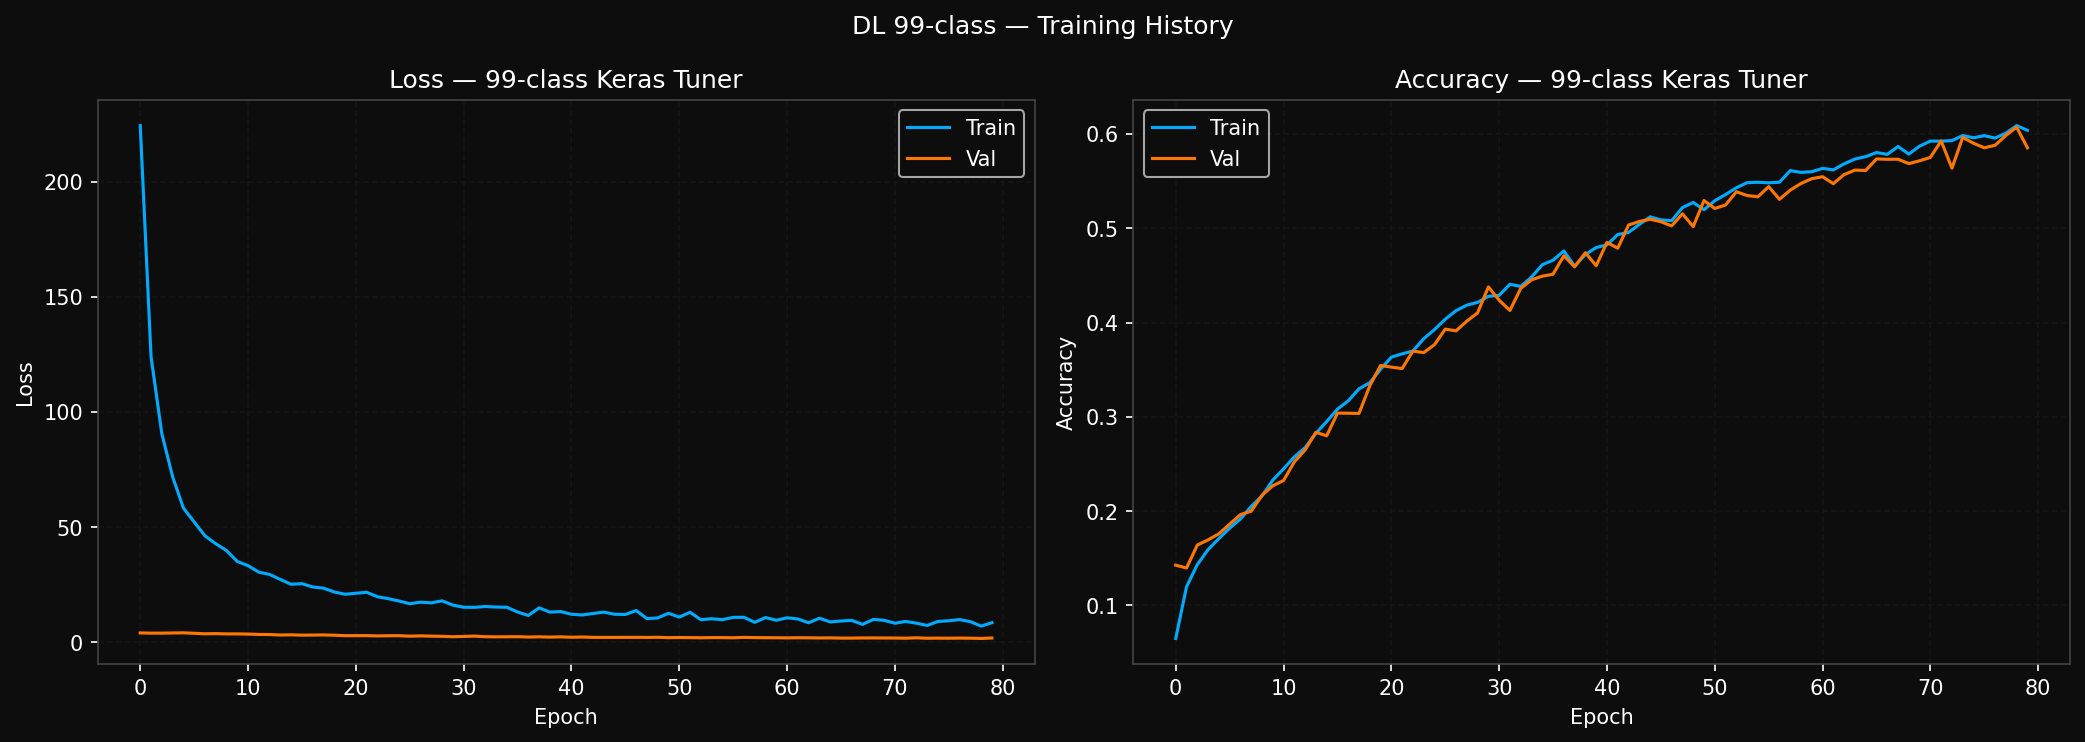

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hist = history.history

axes[0].plot(hist['loss'],     label='Train', color='#00aaff')
axes[0].plot(hist['val_loss'], label='Val',   color='#ff7700')
axes[0].set_title('Loss — 99-class Keras Tuner')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(hist['accuracy'],     label='Train', color='#00aaff')
axes[1].plot(hist['val_accuracy'], label='Val',   color='#ff7700')
axes[1].set_title('Accuracy — 99-class Keras Tuner')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('DL 99-class — Training History', fontsize=12)
plt.tight_layout()
# plt.savefig(os.path.join(plots_path, '05c_history.png'), dpi=200, bbox_inches='tight')
plt.show()

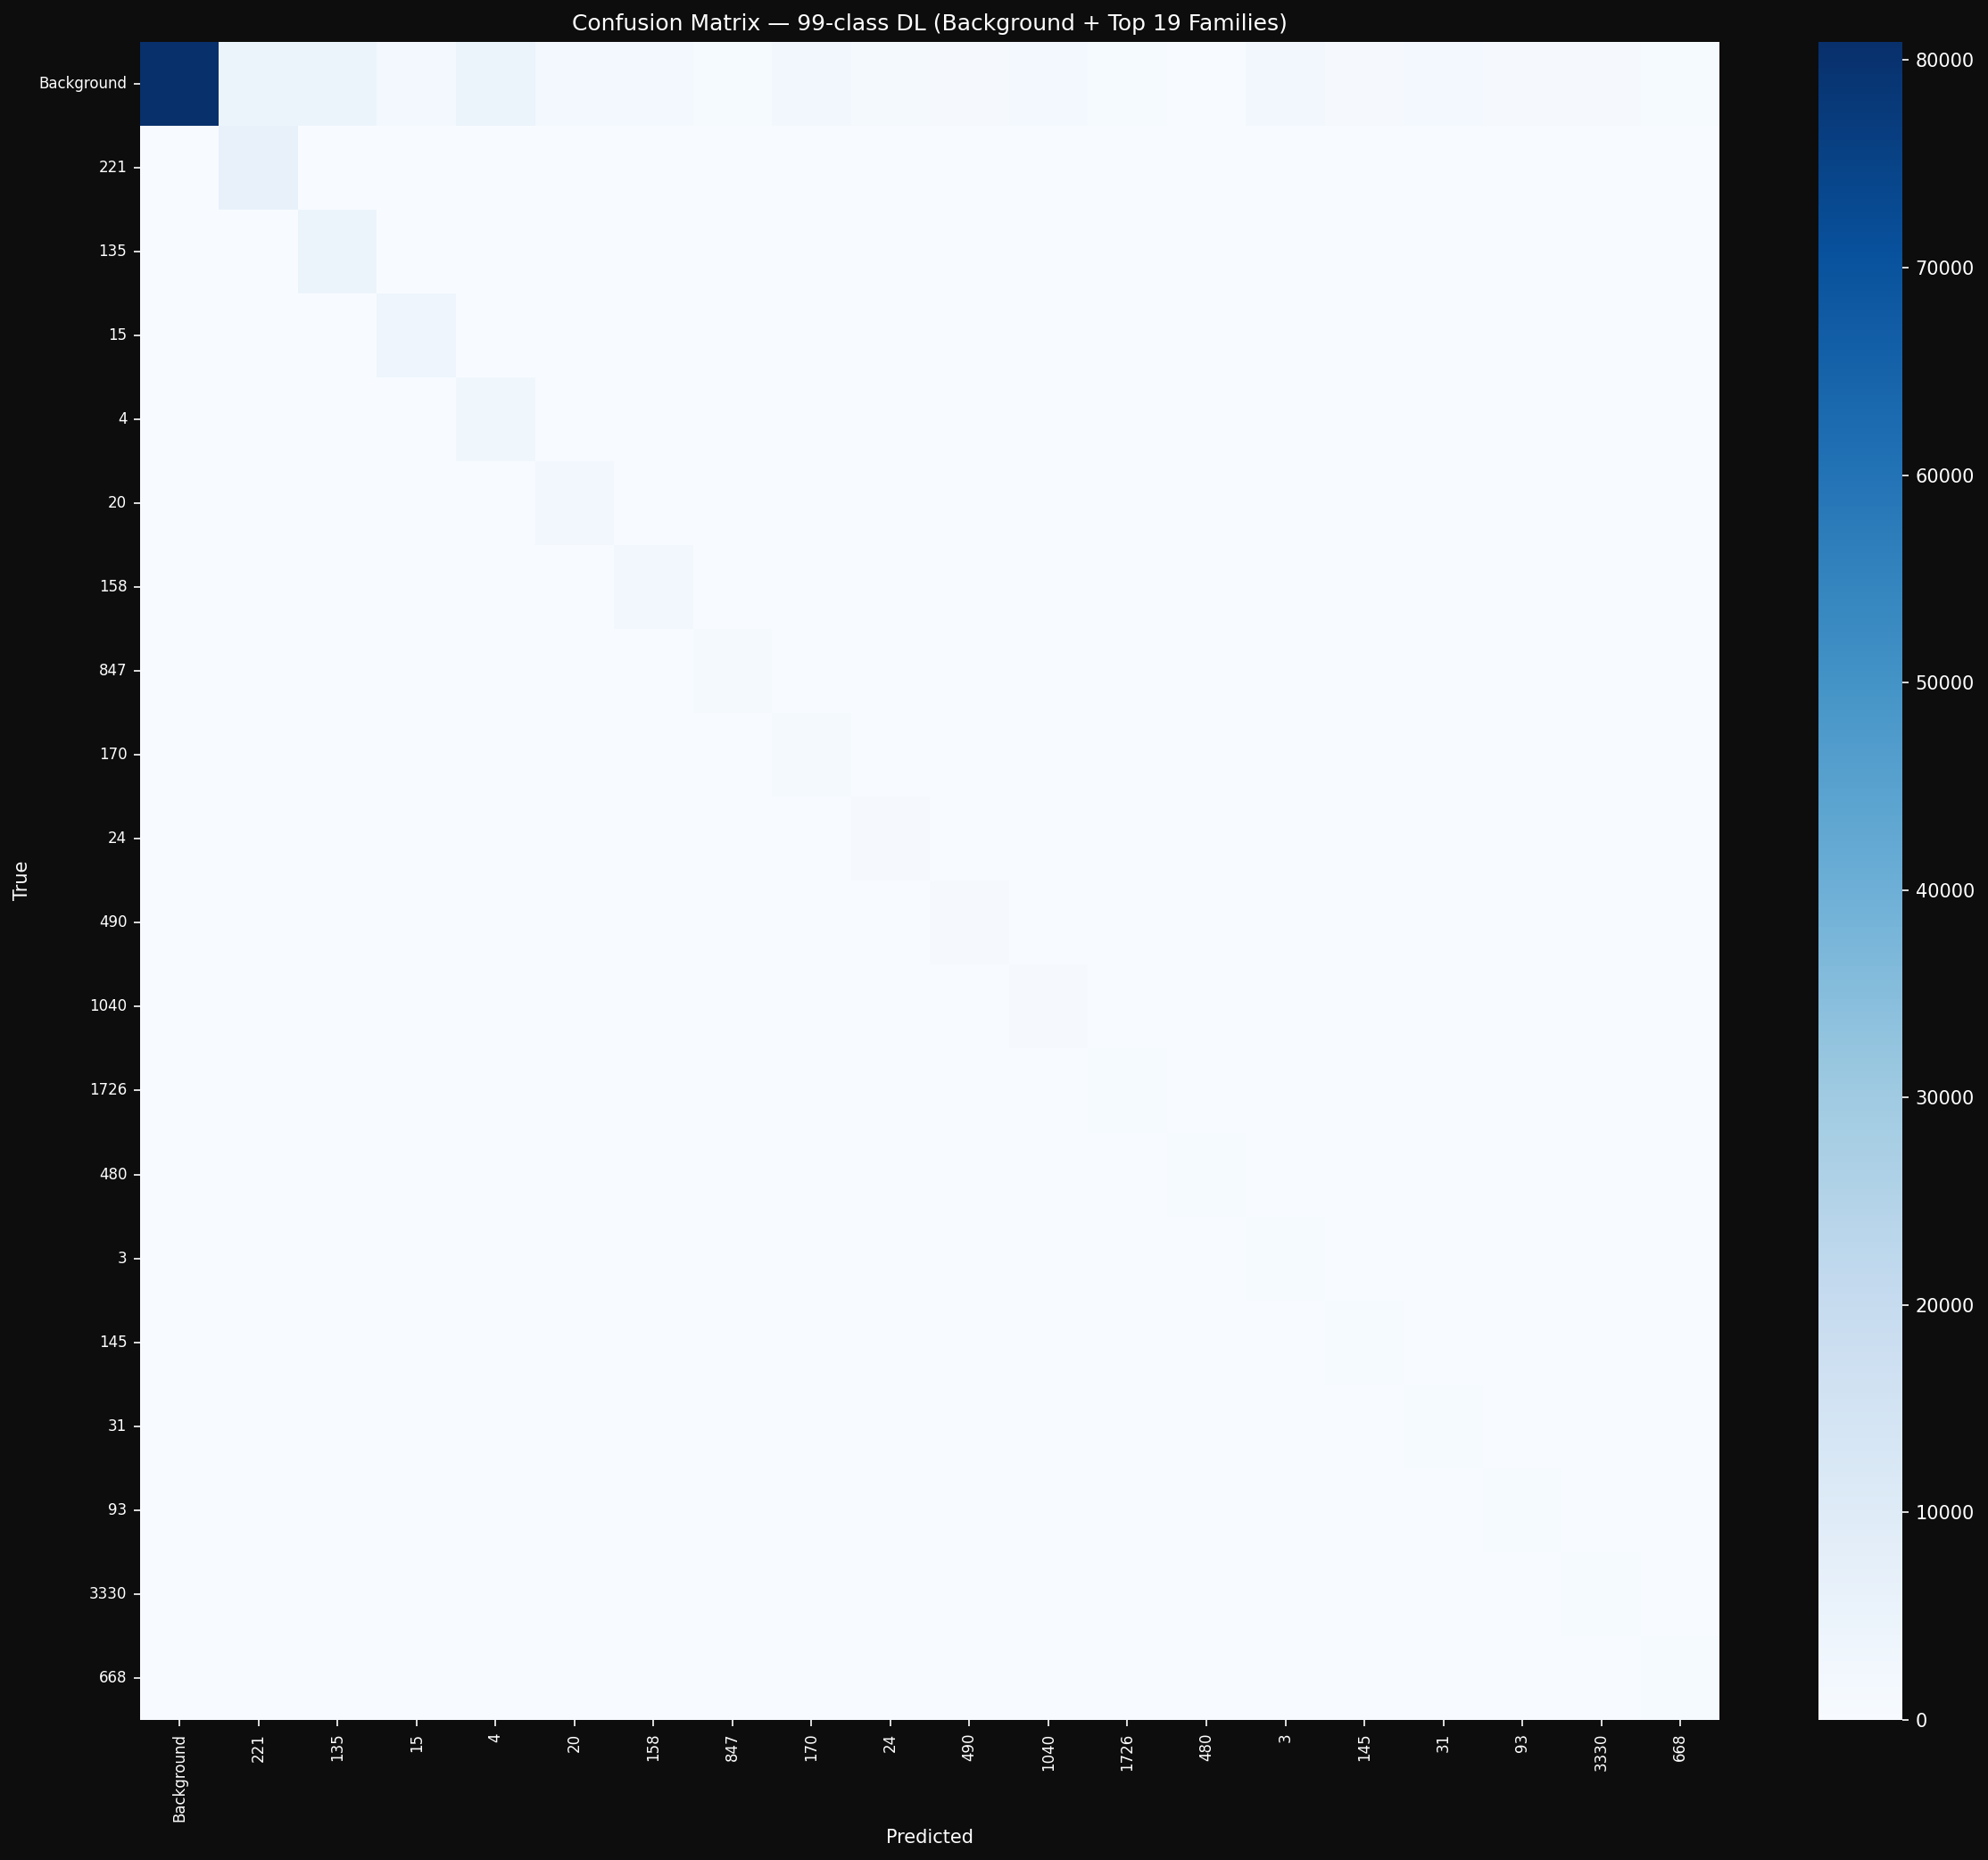

In [12]:
# Include background + top 19 families by size
top19_families = (
    orbital_df[orbital_df['is_family_member']]
    .groupby('family_1').size()
    .sort_values(ascending=False)
    .head(19).index.tolist()
)
top20_classes  = [0] + top19_families   # 0 = background
top20_encoded  = le.transform(top20_classes)
top20_labels   = ['Background'] + [str(f) for f in top19_families]

mask   = np.isin(y_test, top20_encoded)
y_t    = y_test[mask]
y_p    = y_pred[mask]

remap  = {v: i for i, v in enumerate(top20_encoded)}
y_t_r  = np.array([remap[v] for v in y_t])
y_p_r  = np.array([remap.get(v, -1) for v in y_p])

cm = confusion_matrix(y_t_r, y_p_r, labels=list(range(len(top20_classes))))

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(
    cm, annot=False, cmap='Blues',
    xticklabels=top20_labels,
    yticklabels=top20_labels,
    ax=ax
)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix — 99-class DL (Background + Top 19 Families)')
plt.setp(ax.get_xticklabels(), rotation=90, fontsize=8)
plt.setp(ax.get_yticklabels(), rotation=0,  fontsize=8)

plt.tight_layout()
# plt.savefig(os.path.join(plots_path, '05c_confusion_top20.png'), dpi=200, bbox_inches='tight')
plt.show()

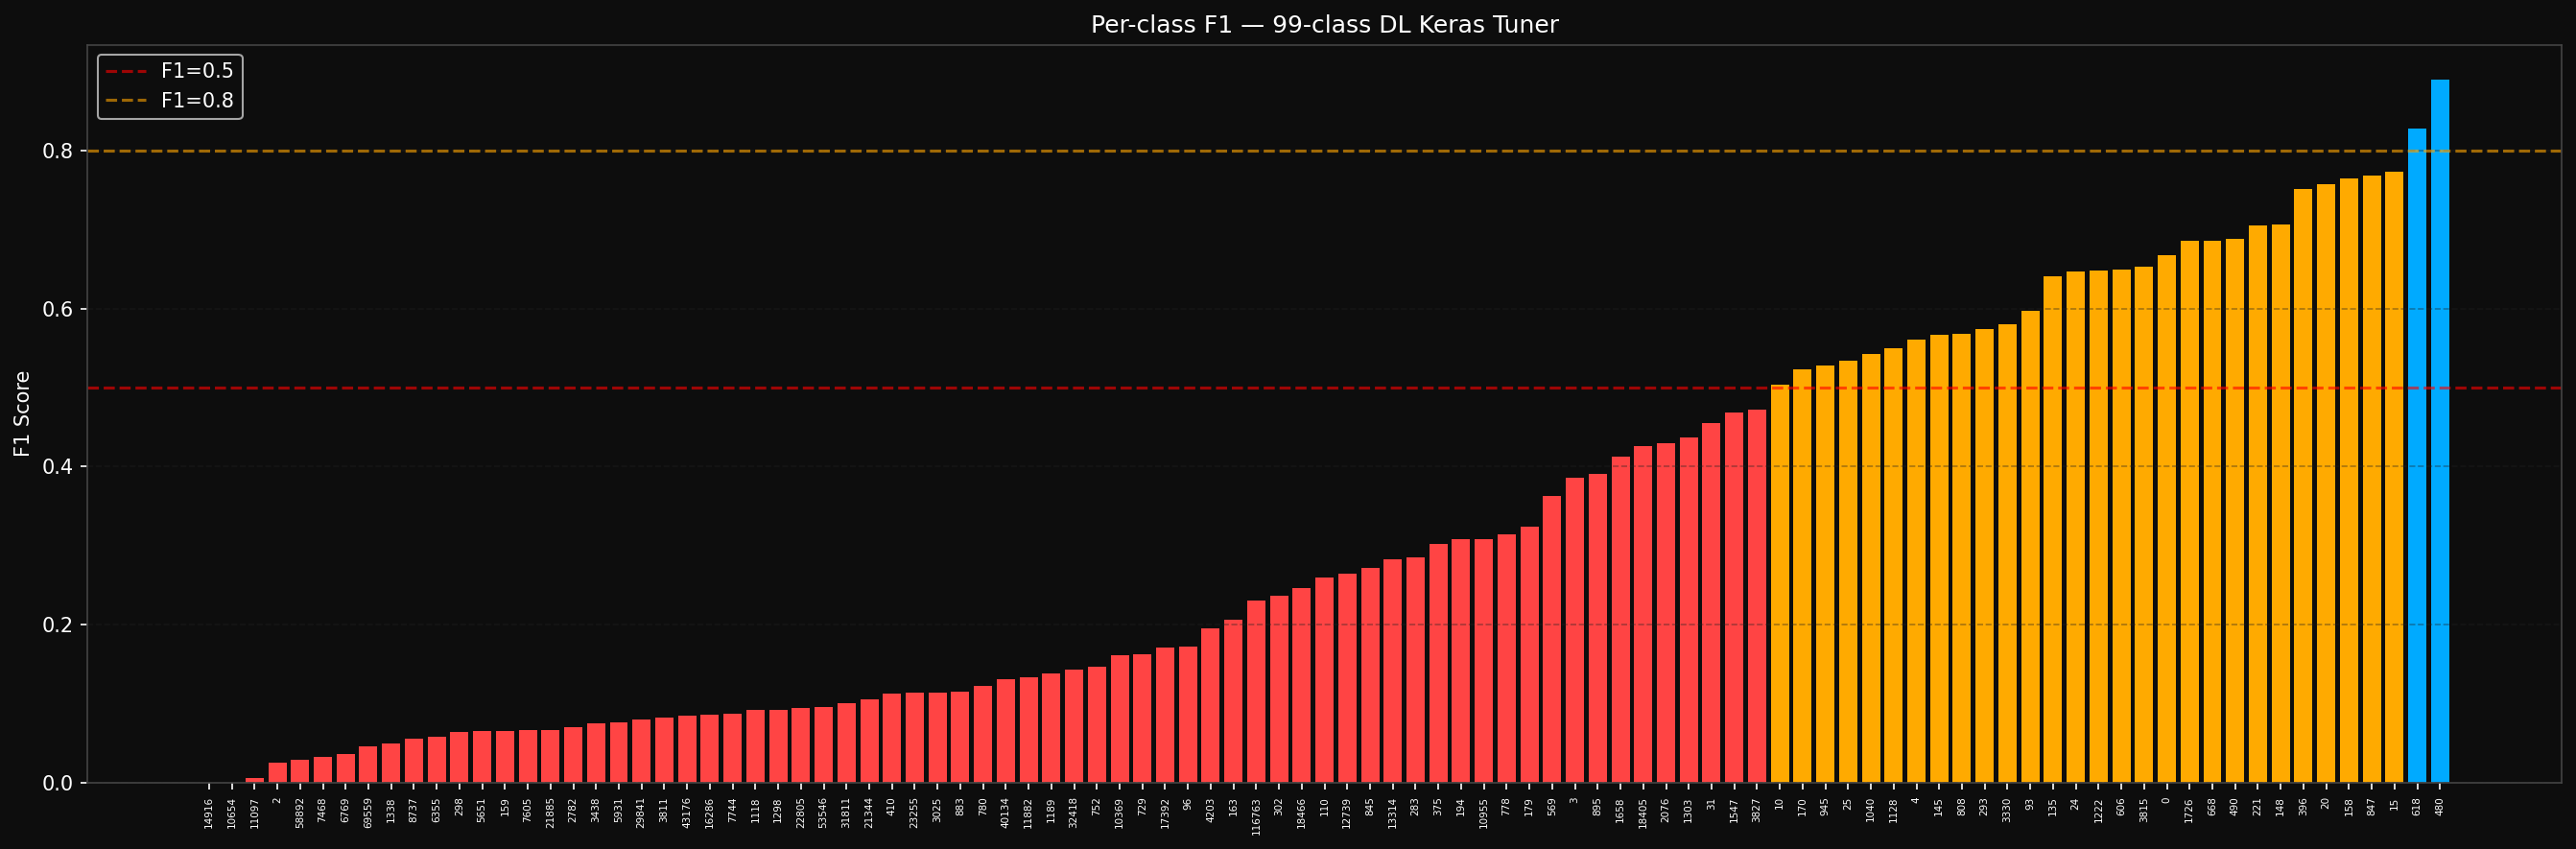

In [13]:
fig, ax = plt.subplots(figsize=(18, 6))

sorted_idx   = np.argsort(per_class_f1)
class_names  = [str(le.classes_[i]) for i in sorted_idx]

colors = ['#ff4444' if f < 0.5 else '#ffaa00' if f < 0.8 else '#00aaff'
          for f in per_class_f1[sorted_idx]]

ax.bar(range(len(per_class_f1)), per_class_f1[sorted_idx],
       color=colors, edgecolor='none')
ax.axhline(0.5, color='red',    linestyle='--', alpha=0.6, label='F1=0.5')
ax.axhline(0.8, color='orange', linestyle='--', alpha=0.6, label='F1=0.8')
ax.set_xticks(range(len(per_class_f1)))
ax.set_xticklabels(class_names, rotation=90, fontsize=5)
ax.set_ylabel('F1 Score')
ax.set_title('Per-class F1 — 99-class DL Keras Tuner')
ax.legend()
ax.grid(True, axis='y')

plt.tight_layout()
# plt.savefig(os.path.join(plots_path, '05c_perclass_f1.png'), dpi=200, bbox_inches='tight')
plt.show()

In [14]:
with open(os.path.join('data', 'results', 'classification_results', '07a_i_multiclass_rf_results.pkl'), 'rb') as f:
    rf_results = pickle.load(f)
with open(os.path.join('data', 'results', 'classification_results', '07a_ii_dl_multiclass_results.pkl'), 'rb') as f:
    dl_base_results = pickle.load(f)
with open(os.path.join('data', 'results', 'classification_results', '07a_iii_tuner_results.pkl'), 'rb') as f:
    tuner_98_results = pickle.load(f)

print(f"\n{'='*75}")
print(f"{'Complete Multiclass Summary':^75}")
print(f"{'='*75}")
print(f"{'Model':<38} {'Classes':>8} {'Acc':>8} {'F1 Macro':>10}")
print(f"{'-'*75}")

for feat_name, res in rf_results.items():
    print(f"{'RF_'+feat_name:<38} {'98':>8} {res['acc']:>8.4f} {res['f1_macro']:>10.4f}")

for feat_name, res in dl_base_results.items():
    print(f"{'DL_Dense_'+feat_name:<38} {'98':>8} {res['acc']:>8.4f} {res['f1_macro']:>10.4f}")

print(f"{'DL_Tuned_98cls_Set_A':<38} {'98':>8} "
      f"{tuner_98_results['acc']:>8.4f} {tuner_98_results['f1_macro']:>10.4f}")

print(f"{'DL_Tuned_99cls_Set_A':<38} {'99':>8} {acc:>8.4f} {f1_macro:>10.4f}")


                        Complete Multiclass Summary                        
Model                                   Classes      Acc   F1 Macro
---------------------------------------------------------------------------
RF_Set_A_orbital                             98   0.9992     0.9919
RF_Set_B_full                                98   0.9992     0.9941
DL_Dense_Set_A_orbital                       98   0.9564     0.9183
DL_Dense_Set_B_full                          98   0.9010     0.8010
DL_Tuned_98cls_Set_A                         98   0.9894     0.9467
DL_Tuned_99cls_Set_A                         99   0.6054     0.3196


In [17]:
print(f"Background Accuracy : {bg_acc:.4f}")
print(f"Family Accuracy     : {fam_acc:.4f}")

# Also check what the model does with halo candidates
bg_load = pd.read_pickle(os.path.join('data', 'results', 'classification_results', '08_background_analysis.pkl'))

# Find test indices that are background halo candidates
# Reconstruct test mask
_, X_test_orig, _, y_test_orig = train_test_split(
    orbital_df[FEATURES_A].values, y,
    test_size=0.2, random_state=42, stratify=y
)

bg_test_mask   = y_test == bg_class_idx
fam_test_mask  = y_test != bg_class_idx

print(f"\nOf background test predictions:")
print(f"  Correctly predicted background : "
      f"{(y_pred[bg_test_mask] == bg_class_idx).sum():,}")
print(f"  Incorrectly assigned to family : "
      f"{(y_pred[bg_test_mask] != bg_class_idx).sum():,}")

print(f"\nOf family test predictions:")
print(f"  Correctly predicted family     : "
      f"{(y_pred[fam_test_mask] == y_test[fam_test_mask]).sum():,}")
print(f"  Assigned to wrong family       : "
      f"{((y_pred[fam_test_mask] != y_test[fam_test_mask]) & (y_pred[fam_test_mask] != bg_class_idx)).sum():,}")
print(f"  Incorrectly labeled background : "
      f"{(y_pred[fam_test_mask] == bg_class_idx).sum():,}")

Background Accuracy : 0.5008
Family Accuracy     : 0.9719

Of background test predictions:
  Correctly predicted background : 80,898
  Incorrectly assigned to family : 80,630

Of family test predictions:
  Correctly predicted family     : 44,823
  Assigned to wrong family       : 1,295
  Incorrectly labeled background : 3


In [16]:
save_dict = {
    'best_hps': {
        'n_layers':      best_hps.get('n_layers'),
        'units_first':   best_hps.get('units_first'),
        'dropout_rate':  best_hps.get('dropout_rate'),
        'learning_rate': best_hps.get('learning_rate'),
        'l2_reg':        best_hps.get('l2_reg'),
        'use_batchnorm': best_hps.get('use_batchnorm'),
    },
    'history':       history.history,
    'y_test':        y_test,
    'y_pred':        y_pred,
    'acc':           acc,
    'f1_macro':      f1_macro,
    'f1_weighted':   f1_weighted,
    'per_class_f1':  per_class_f1,
    'bg_acc':        bg_acc,
    'fam_acc':       fam_acc,
}

with open(os.path.join('data', 'results', 'classification_results', '09_99class_tuner_results.pkl'), 'wb') as f:
    pickle.dump(save_dict, f)

print("Saved → data/results/09_99class_tuner_results.pkl")

Saved → data/results/09_99class_tuner_results.pkl
